# Recyclable Item Detector - Google Colab Test Notebook

This notebook tests the recyclable item detector code using YOLOv8 object detection.

## Features:
- Detects recyclable items (bottles, cups, wine glasses, vases) in images
- Uses YOLOv8n pretrained model
- Provides recycling rules based on ZIP codes
- Integrates with OpenAI API for location-specific recycling information

## 1. Install Required Dependencies

In [ ]:
# Install required packages
!pip install ultralytics opencv-python-headless Pillow numpy requests 'uszipcode<1.0.0' openai

print("\n✅ All dependencies installed successfully!")

## 2. Import Libraries

In [ ]:
import io
import json
import os
import time
from pathlib import Path
from PIL import Image, ImageOps
import numpy as np
from ultralytics import YOLO
import requests
from uszipcode import SearchEngine
from openai import OpenAI
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display, HTML

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 3. Initialize ZIP Code Search Engine and Load YOLO Model

In [ ]:
# Initialize uszipcode search engine
zip_search_engine = SearchEngine()
print("✅ ZIP code search engine initialized")

# Load YOLOv8n model (will download if not already cached)
print("Loading YOLO model (this may take a moment on first run)...")
model = YOLO("yolov8n.pt")
print("✅ YOLO model loaded successfully!")

✅ ZIP code search engine initialized
Loading YOLO model (this may take a moment on first run)...
✅ YOLO model loaded successfully!


## 4. Define Helper Functions

In [ ]:
# Define recyclable items we're interested in detecting
RECYCLABLE_COCO = {"bottle", "cup", "wine glass", "vase"}

# Initialize recycling rules structure
rules_map = {
    "zips": {},
    "cities": {},
    "states": {},
    "national_default": {
        "default": "Check your local recycling guidelines for specific instructions.",
        "bottle": "Most plastic and glass bottles are recyclable. Rinse before recycling.",
        "cup": "Paper cups often not recyclable due to plastic lining. Check local rules.",
        "wine glass": "Glass items typically not accepted curbside. Take to glass recycling center.",
        "vase": "Glass vases may require special handling. Contact local waste management."
    }
}

def validate_zip(zip_code: str) -> bool:
    """Validate that the ZIP code is a real 5-digit US ZIP code."""
    if not zip_code or len(zip_code) != 5 or not zip_code.isdigit():
        return False

    result = zip_search_engine.by_zipcode(zip_code)
    return result and result.zipcode is not None

def zip_to_location(zip_code: str) -> dict | None:
    """Resolve ZIP code to city, county, and state information."""
    result = zip_search_engine.by_zipcode(zip_code)

    if result and result.zipcode:
        return {
            "zipcode": result.zipcode,
            "city": result.major_city or result.post_office_city,
            "county": result.county,
            "state": result.state,
            "state_abbr": result.state_abbr,
        }
    return None

def generate_lookup_links(zip_code: str, location: dict | None) -> dict:
    """Generate helpful lookup links when no cached rules exist."""
    city = location.get("city", "") if location else ""
    state = location.get("state_abbr", "") if location else ""

    location_str = f"{city}, {state}" if city and state else f"ZIP {zip_code}"

    return {
        "default": f"No cached rules for {location_str}. Use the links below to find local recycling information.",
        "earth911_link": f"https://search.earth911.com/?query=recycling&postal_code={zip_code}",
        "company": f"Search earth911.com or contact your local waste management for {location_str}",
        "_fetched_at": int(time.time())
    }

def fetch_recycling_rules_with_openai(zip_code: str, api_key: str = None) -> dict:
    """Fetch recycling rules using OpenAI API if available."""
    location = zip_to_location(zip_code)

    # Try using OpenAI if API key is provided
    if api_key:
        try:
            client = OpenAI(api_key=api_key)
            city = location.get("city", "") if location else ""
            state = location.get("state_abbr", "") if location else ""
            loc_str = f"{city}, {state}" if city and state else f"ZIP {zip_code}"

            prompt = f"""
            You are a waste management expert.
            Find the recycling rules for {loc_str} (ZIP {zip_code}).
            Identify the specific company that does residential garbage collection for this area.

            Provide a JSON object with these keys:
            - "company": Name of the waste management provider.
            - "bottle": Rule for plastic/glass bottles.
            - "cup": Rule for disposable cups (paper/plastic).
            - "wine glass": Rule for wine glasses.
            - "vase": Rule for glass vases.
            - "default": General recycling summary.

            Return ONLY raw JSON.
            """

            response = client.chat.completions.create(
                model='gpt-4o',
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"}
            )
            text = response.choices[0].message.content.strip()

            # Clean markdown formatting if present
            if text.startswith("```json"):
                text = text[7:]
            if text.startswith("```"):
                text = text[3:]
            if text.endswith("```"):
                text = text[:-3]

            data = json.loads(text)
            data["_fetched_at"] = int(time.time())
            return data

        except Exception as e:
            print(f"⚠️ OpenAI lookup failed: {e}. Using fallback links.")

    # Fallback: Generate lookup links
    new_rules = generate_lookup_links(zip_code, location)

    if location:
        new_rules.update({
            "bottle": f"Most areas accept bottles in curbside recycling. Check {location['city']}'s municipal website.",
            "cup": "Compostable cups may be accepted if your area has organics collection; otherwise trash.",
            "wine glass": "Typically not accepted curbside; check for glass drop-off centers in your area.",
            "vase": f"Glass items may require special handling. Contact {location['city']} waste management.",
        })

    return new_rules

def get_recycling_rules(zip_code: str, api_key: str = None) -> tuple[dict, str]:
    """Get recycling rules with fallback to national defaults."""
    # Check cache first
    if zip_code in rules_map.get("zips", {}):
        return rules_map["zips"][zip_code], f"ZIP {zip_code} (cached)"

    # Try fetching new rules
    fetched_rules = fetch_recycling_rules_with_openai(zip_code, api_key)
    if fetched_rules:
        # Cache the fetched rules
        if "zips" not in rules_map:
            rules_map["zips"] = {}
        rules_map["zips"][zip_code] = fetched_rules
        return fetched_rules, f"ZIP {zip_code} (newly fetched)"

    # Fallback to national default
    return rules_map.get("national_default", {}), "national default"

print("✅ Helper functions defined!")

✅ Helper functions defined!


## 5. Configure OpenAI API Key (Optional)

If you want to use location-specific recycling information fetched via OpenAI, set your API key here:

In [ ]:
import os
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

## 6. Upload and Analyze Image

Upload an image to detect recyclable items:

Please upload an image containing recyclable items:


Saving Peets_cup.jpg to Peets_cup (2).jpg

📷 Uploaded Image:


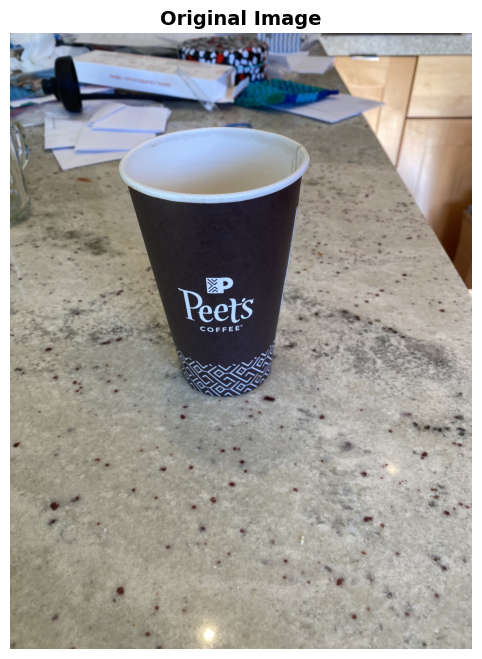

✅ Image loaded successfully!


In [ ]:
# Upload image
print("Please upload an image containing recyclable items:")
uploaded = files.upload()

if uploaded:
    # Get the first uploaded file
    filename = list(uploaded.keys())[0]
    image_data = uploaded[filename]

    # Open and process image
    img = Image.open(io.BytesIO(image_data))

    # Fix image rotation based on EXIF orientation data
    try:
        img = ImageOps.exif_transpose(img)
    except Exception:
        pass

    img = img.convert("RGB")

    # Display original image
    print("\n📷 Uploaded Image:")
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Original Image', fontsize=14, fontweight='bold')
    plt.show()

    print("✅ Image loaded successfully!")
else:
    print("❌ No image uploaded")

## 7. Run Object Detection

🔍 Running object detection...

0: 640x480 1 cup, 1 pizza, 194.9ms
Speed: 5.5ms preprocess, 194.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

🎯 Detection Results:


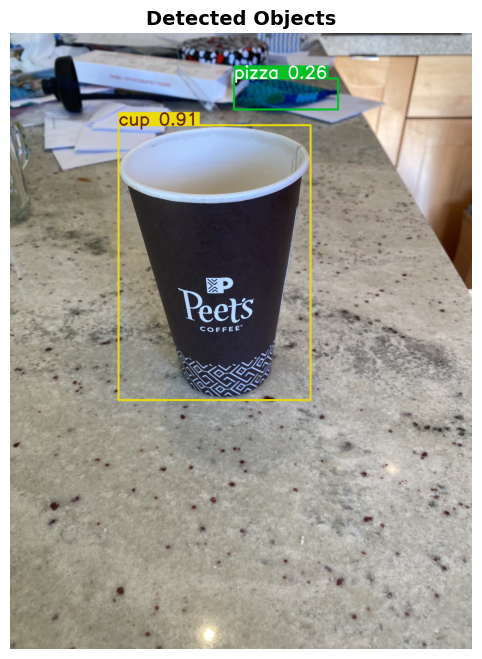


📊 ALL DETECTED OBJECTS:
  • cup — confidence: 91.09%
  • pizza — confidence: 25.72%

♻️  RECYCLABLE ITEMS FOUND:
  ✅ cup — confidence: 91.09%

✅ Detection complete!


In [ ]:
if uploaded:
    print("🔍 Running object detection...")

    # Run YOLO detection
    results = model(np.array(img), imgsz=640)

    # Get first result
    r = results[0]
    annotated = r.plot()

    # Display annotated image
    print("\n🎯 Detection Results:")
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title('Detected Objects', fontsize=14, fontweight='bold')
    plt.show()

    # Extract detected class names and confidences
    detected = []
    if hasattr(r, "boxes") and r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            cls_idx = int(box.cls.cpu().numpy()[0]) if hasattr(box, "cls") else None
            conf = float(box.conf.cpu().numpy()[0]) if hasattr(box, "conf") else None
            name = r.names[cls_idx] if cls_idx is not None else ""
            detected.append((name, conf))

    # Filter recyclable items
    recyclable_found = [d for d in detected if d[0] in RECYCLABLE_COCO]

    # Display results
    print("\n" + "="*60)
    print("📊 ALL DETECTED OBJECTS:")
    print("="*60)
    if detected:
        for name, conf in detected:
            print(f"  • {name} — confidence: {conf:.2%}")
    else:
        print("  No objects detected.")

    print("\n" + "="*60)
    print("♻️  RECYCLABLE ITEMS FOUND:")
    print("="*60)
    if recyclable_found:
        for name, conf in recyclable_found:
            print(f"  ✅ {name} — confidence: {conf:.2%}")
    else:
        print("  No recyclable items detected.")

    print("\n✅ Detection complete!")
else:
    print("⚠️ Please upload an image first (run the previous cell)")

## 8. Get Location-Specific Recycling Instructions

Enter a ZIP code to get recycling rules for your area:

In [ ]:
if uploaded and recyclable_found:
    # Get ZIP code from user
    zip_code = input("Enter your 5-digit ZIP code (or press Enter to skip): ").strip()

    if zip_code:
        if validate_zip(zip_code):
            print(f"\n🔍 Looking up recycling rules for ZIP {zip_code}...\n")

            # Get location info
            location = zip_to_location(zip_code)
            if location:
                print(f"📍 Location: {location['city']}, {location['state_abbr']} ({location['county']} County)")

            # Get recycling rules
            local_rules, source = get_recycling_rules(zip_code, OPENAI_API_KEY)

            print(f"ℹ️  Rules source: {source}\n")

            # Show waste management provider
            provider = local_rules.get("company") or local_rules.get("service_provider") or local_rules.get("provider")
            if provider:
                print(f"🏢 Waste service provider: {provider}\n")

            # Show Earth911 link if available
            if "earth911_link" in local_rules:
                print(f"🔗 Find recycling centers: {local_rules['earth911_link']}\n")

            # Show recycling instructions for detected items
            print("="*60)
            print("📋 RECYCLING INSTRUCTIONS FOR DETECTED ITEMS:")
            print("="*60)
            for name, conf in recyclable_found:
                instr = local_rules.get(name, local_rules.get("default", "No specific instruction available."))
                print(f"\n• {name.upper()}:")
                print(f"  {instr}")

        else:
            print(f"\n❌ '{zip_code}' is not a valid US ZIP code.")
            print("\nUsing national default recycling guidelines:")
            print("="*60)
            for name, conf in recyclable_found:
                instr = rules_map["national_default"].get(name, rules_map["national_default"].get("default", "Check local guidelines."))
                print(f"\n• {name.upper()}:")
                print(f"  {instr}")
    else:
        print("\nUsing national default recycling guidelines:")
        print("="*60)
        for name, conf in recyclable_found:
            instr = rules_map["national_default"].get(name, rules_map["national_default"].get("default", "Check local guidelines."))
            print(f"\n• {name.upper()}:")
            print(f"  {instr}")
else:
    if not uploaded:
        print("⚠️ Please upload an image first")
    elif not recyclable_found:
        print("ℹ️ No recyclable items detected in the image")

Enter your 5-digit ZIP code (or press Enter to skip): 94024

🔍 Looking up recycling rules for ZIP 94024...

📍 Location: Los Altos, CA (Santa Clara County County)
ℹ️  Rules source: ZIP 94024 (newly fetched)

🏢 Waste service provider: Mission Trail Waste Systems

📋 RECYCLING INSTRUCTIONS FOR DETECTED ITEMS:

• CUP:
  Plastic cups are recyclable, but paper cups often are not due to wax coatings. Check if there is a plastic lining, as these cannot be recycled.


## 9. Test with Sample URL (Optional)

You can also test with an image from a URL:

In [ ]:
# Example: Test with an image URL
def test_with_url(image_url: str, zip_code: str = None):
    """Test the detector with an image from a URL."""
    print(f"📥 Downloading image from: {image_url}")

    try:
        response = requests.get(image_url, timeout=10)
        response.raise_for_status()

        img = Image.open(io.BytesIO(response.content))
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")

        # Display image
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Downloaded Image', fontsize=14, fontweight='bold')
        plt.show()

        # Run detection
        print("\n🔍 Running detection...")
        results = model(np.array(img), imgsz=640)
        r = results[0]
        annotated = r.plot()

        plt.figure(figsize=(10, 8))
        plt.imshow(annotated)
        plt.axis('off')
        plt.title('Detection Results', fontsize=14, fontweight='bold')
        plt.show()

        # Extract results
        detected = []
        if hasattr(r, "boxes") and r.boxes is not None and len(r.boxes) > 0:
            for box in r.boxes:
                cls_idx = int(box.cls.cpu().numpy()[0])
                conf = float(box.conf.cpu().numpy()[0])
                name = r.names[cls_idx]
                detected.append((name, conf))

        recyclable_found = [d for d in detected if d[0] in RECYCLABLE_COCO]

        print("\n" + "="*60)
        print("🎯 RESULTS:")
        print("="*60)
        print(f"\nAll detected: {len(detected)} objects")
        for name, conf in detected:
            print(f"  • {name} ({conf:.2%})")

        print(f"\nRecyclable items: {len(recyclable_found)} items")
        for name, conf in recyclable_found:
            print(f"  ✅ {name} ({conf:.2%})")

        if zip_code and recyclable_found:
            if validate_zip(zip_code):
                local_rules, source = get_recycling_rules(zip_code, OPENAI_API_KEY)
                print(f"\n📋 Recycling instructions for ZIP {zip_code}:")
                for name, conf in recyclable_found:
                    instr = local_rules.get(name, local_rules.get("default", "Check local guidelines."))
                    print(f"  • {name}: {instr}")

        return detected, recyclable_found

    except Exception as e:
        print(f"❌ Error: {e}")
        return None, None

# Example usage (uncomment to test):
# test_with_url("https://example.com/bottle.jpg", "94102")

print("✅ URL testing function defined. Call test_with_url(url, zip_code) to use it.")

✅ URL testing function defined. Call test_with_url(url, zip_code) to use it.


## Summary

This notebook demonstrates:
1. ✅ YOLOv8 object detection for recyclable items
2. ✅ ZIP code validation and location lookup
3. ✅ Integration with OpenAI API for local recycling rules
4. ✅ Fallback to generic recycling guidelines
5. ✅ Support for both uploaded and URL-based images

**Recyclable items detected:** bottles, cups, wine glasses, vases

**Next steps:**
- Upload your own images to test
- Add your OpenAI API key for location-specific rules
- Test with different ZIP codes
- Modify the recyclable items list for your needs